In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = {
  'Models': ['pcv1', 'pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536',
             'pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536',
             'pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536',
             'pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536',
            'pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536'],
  'Context_window': [512, 512, 512, 512, 1024, 1024, 1024, 2048, 2048, 2048, 4096, 4096, 4096, 8192, 8192, 8192],
  'AUROC': [0.6902, 0.6222, 0.6535, 0.6695, 0.636, 0.6757, 0.6932, 0.6501, 0.6983, 0.7127, 0.658, 0.7095, 0.7257, 0.6555, 0.7077, 0.7245]
}

df = pd.DataFrame(data)

In [3]:
df

,Models,Context_window,AUROC
0,pcv1,512,0.6902
1,pcv2-l24-d0768,512,0.6222
2,pcv2-l48-d1024,512,0.6535
3,pcv2-l48-d1536,512,0.6695
4,pcv2-l24-d0768,1024,0.6360
5,pcv2-l48-d1024,1024,0.6757
6,pcv2-l48-d1536,1024,0.6932
7,pcv2-l24-d0768,2048,0.6501
8,pcv2-l48-d1024,2048,0.6983
9,pcv2-l48-d1536,2048,0.7127


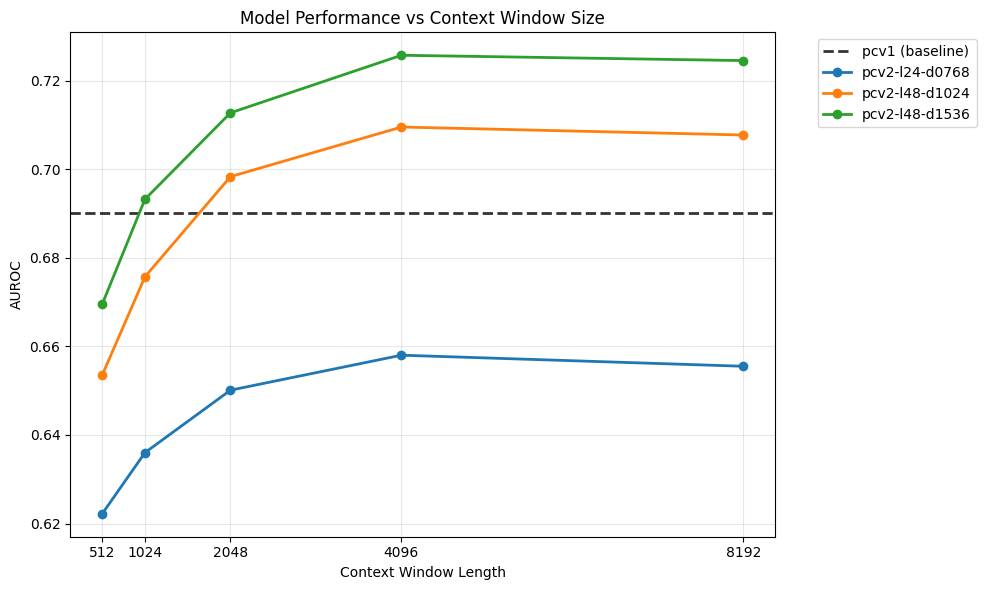

In [4]:
plt.figure(figsize=(10, 6))

baseline_auroc = df[df['Models'] == 'pcv1']['AUROC'].iloc[0]

plt.axhline(y=baseline_auroc, color='black', linestyle='--', linewidth=2, 
          label='pcv1 (baseline)', alpha=0.8)

other_models = df[df['Models'] != 'pcv1']
models = other_models['Models'].unique()

for model in models:
  model_data = other_models[other_models['Models'] == model]
  plt.plot(model_data['Context_window'], model_data['AUROC'], 
          marker='o', linewidth=2, markersize=6, label=model)

plt.xlabel('Context Window Length')
plt.ylabel('AUROC')
plt.title('Model Performance vs Context Window Size')

plt.xticks(df['Context_window'].unique())
# plt.ylim(0.6, None)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_vs_context_window.pdf', format='pdf', bbox_inches='tight')
plt.show()